In [47]:
import os
os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/"
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import datetime
import cftime
import time

In [142]:
def preprocess_v(ds): 
    ds = ds[['vomecrty', 'e3v']]
    ds = ds.rename({'depthv':'depth'})
    #ds = ds.rename({'nav_lat_grid_V':'nav_lat'})
    #ds = ds.rename({'nav_lon_grid_V':'nav_lon'})
    return ds

def preprocess_u(ds): 
    ds = ds[['vozocrtx', 'e3u']]
    ds = ds.rename({'depthu':'depth'})
    #ds = ds.rename({'nav_lat_grid_U':'nav_lat'})
    #ds = ds.rename({'nav_lon_grid_U':'nav_lon'})
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all

def preprocess_t(ds): 
    ds = ds[['sossheig','vosaline', 'votemper', 'somxlts','e3t']] # 'vosaline', 'votemper', 
    #ds = ds.rename({'deptht':'depth'})
    #ds = ds.rename({'nav_lat_grid_T':'nav_lat'})
    #ds = ds.rename({'nav_lon_grid_T':'nav_lon'})
    return ds

def get_files(path, runid, times):
    #need both the u and v components of velocity
    mdl_files_v = []
    #mdl_files_u = []
    mdl_files_t = []
    for t in times:
        mdl_files_v.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridV.nc")
        #mdl_files_u.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridU.nc")
        mdl_files_t.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridT.nc")
    dv = xr.open_mfdataset(mdl_files_v, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_v) #chunks={'time_counter':73, 'depth':25, 'y_grid_V':100, 'x_grid_V':136,'y_grid_V_3D_inner':100, 'x_grid_V_3D_inner':136, 'grid_V_3D_inner': 25})
    print('done loading v')
    #du = xr.open_mfdataset(mdl_files_u, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_u, chunks={'time_counter': 10, 'deptht':25, 'y_grid_T':400, 'x_grid_T':272,'y_grid_T_3D_inner':400, 'x_grid_T_3D_inner':272, 'grid_T_3D_inner': 25})
    #print('done loading u')
    dt = xr.open_mfdataset(mdl_files_t, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_t) #chunks={'time_counter':73, 'depth':25, 'y_grid_V':100, 'x_grid_V':136,'y_grid_V_3D_inner':100, 'x_grid_V_3D_inner':136, 'grid_V_3D_inner': 25}, preprocess=preprocess_t)
    print('done loading t')
    return dv , dt #, du

In [3]:
def time_bounds(startyear, startmonth, startday, endyear, endmonth, endday):
    return [startyear, startmonth, startday, endyear, endmonth, endday]

def get_times(dates):
    start_time = datetime.date(dates[0], dates[1], dates[2])
    end_time = datetime.date(dates[3], dates[4], dates[5])

    #figure out all the dates we have model files
    delta = end_time - start_time
    times = []

    i = 0
    while i < delta.days+1:
        t = start_time + datetime.timedelta(days=i)
        if t.month == 2 and t.day == 29:
            t = datetime.date(t.year, 3, 1)
            i = i+6
        else:
            i = i+5
        times.append(t)

    return times

In [154]:
def barotropic_sf(ds, ds_mask):

    v_t = ds['vomecrty'][:,:,:,:]
    v_z = ds['e3v'][:, :, :,:]
    m = (v_t * v_z).mean('time_counter')
    
    v_x = ds_mask['e1v'][0, :,:]
    
    btsf = np.cumsum(np.sum(m, axis = 0) * v_x, axis = 1)
    print(btsf.shape)
    
    return btsf

def barotropic_plotter(ds, ds_mask, btsfs, labels =[]):
    num = len(btsfs)

    fig, axes = plt.subplots(num,1, figsize=(6,6))
    plt.rcParams['figure.constrained_layout.use'] = True

    for x in range(num):
        sf = np.where(ds_mask['vmask'][0,0,250:450,150:375], btsfs[x][250:450,150:375] / 1e6, np.nan)
        b = axes[x].contourf(sf, np.arange(-80, 80, 10), cmap = 'coolwarm')
        axes[x].set_title(labels[x])
        axes[x].set_ylabel('Latitude')
        axes[x].set_yticks(np.arange(25,200, 25), np.trunc(ds_mask.nav_lat.values[275:450, 150][::25] * 100) / 100) 
            
        axes[x].set_xticks([])

        
    axes[-1].set_xlabel('Longitude')
    axes[-1].set_xticks(np.arange(25,225, 45), np.trunc(ds_mask.nav_lon.values[250, 175:375][::45] * 100) / 100)

    fig.suptitle('2005-2015 ANHA4 Barotropic Streamfunction (Sv)')
    fig.colorbar(b, ax = axes[:])
    plt.savefig('/mnt/storage5/grace/data/figs/barotropic.jpg')
    plt.show()


def overturning_sf(ds, ds_mask):

    v_t = ds['vomecrty'][:,:,:,:]
    v_z = ds['e3v'][:, :, :,:]
    m = (v_t * v_z).mean('time_counter')
    
    v_x = ds_mask['e1v'][0, :,:]
    temp = np.sum(m * v_x, axis = 2)
    #temp = np.where(temp != 0, temp, np.nan)
    mosf = np.cumsum(temp, axis = 0)
    print(mosf.shape)
    return mosf
    
def mld_calc(ds, ds_mask, mld, season):
    
    mlds_seas = {'s_label': season}
    
    mldd = mld[:,250:450,150:375].groupby('time_counter.season')[season].mean('time_counter')
    #v = np.where(ds_mask['tmask'][0,0,250:450,150:375], mldd, np.nan)
    mlds_seas['vals'] = mldd
    mlds_seas['maxes'] = np.nanmax(mldd)
    mlds_seas['mins'] = np.nanmin(mldd)
    
    return mlds_seas    

def ssh_plotter(ds, ds_mask, sshs, labels = []):

    fig, axes = plt.subplots(len(sshs), 1, figsize=(6,6))
    plt.rcParams['figure.constrained_layout.use'] = True

    min = np.nanmin([sshs[0]['mins'], sshs[1]['maxes']])
    max = np.nanmax([sshs[0]['maxes'], sshs[1]['maxes']])

    m = np.max(np.abs([min,max]))

    for x in range(len(sshs)):
        
        b = axes[x].contourf(sshs[x]['vals'], np.arange(-m, m, (max-min)/20), cmap = 'coolwarm')#, extend='min')
        axes[x].set_title(labels[x])
        axes[x].set_ylabel('Latitude')
        axes[x].set_yticks(np.arange(25,200, 25), np.trunc(ds_mask.nav_lat.values[275:450, 150][::25] * 100) / 100)
        axes[x].set_xticks([])

    axes[-1].set_xlabel('Longitude')
    axes[-1].set_xticks(np.arange(25,225, 45), np.trunc(ds_mask.nav_lon.values[250, 175:375][::45] * 100) / 100)

    fig.suptitle('2005-2015 ANHA4 SSH Trends (m/yr)')
    fig.colorbar(b, ax = axes[:])
    plt.savefig('/mnt/storage5/grace/data/figs/ssh_trends.jpg')
    plt.show()

In [12]:
anha4mask = xr.open_dataset('/mnt/storage4/grace/grace/data/model_masks/ANHA4_mesh_mask.nc')

In [143]:
dates = time_bounds(2005, 1, 5, 2014, 12, 31)
times = get_times(dates)
v_teos, t_teos = get_files('/mnt/storage5/grace/data/EGK502/', 'EGK502', times) 
v_eos, t_eos = get_files('/mnt/storage5/grace/data/EGK501t/', 'EGK501t', times) 

done loading v
done loading t
done loading v
done loading t


In [ ]:
anha4mask['e1v'] = anha4mask['e1v'].rename({'y':'y_grid_V', 'x':'x_grid_V'})

In [144]:
v_teos['e3v'] = v_teos['e3v'].rename({'y_grid_V_3D_inner':'y_grid_V', 'x_grid_V_3D_inner':'x_grid_V', 'grid_V_3D_inner':'depth' })
v_eos['e3v'] = v_eos['e3v'].rename({'y_grid_V_3D_inner':'y_grid_V', 'x_grid_V_3D_inner':'x_grid_V', 'grid_V_3D_inner':'depth' })

t_teos['e3t'] = t_teos['e3t'].rename({'y_grid_T_3D_inner':'y_grid_T', 'x_grid_T_3D_inner':'x_grid_T', 'grid_T_3D_inner':'depth' })
t_eos['e3t'] = t_eos['e3t'].rename({'y_grid_T_3D_inner':'y_grid_T', 'x_grid_T_3D_inner':'x_grid_T', 'grid_T_3D_inner':'depth' })

In [145]:
v_eos = v_eos.chunk({'time_counter':73, 'x_grid_V':272, 'depth':50, 'y_grid_V':250})
v_teos = v_teos.chunk({'time_counter':73, 'x_grid_V':272, 'depth':50, 'y_grid_V':250})

t_eos = t_eos.chunk({'time_counter':73, 'x_grid_T':272, 'depth':50, 'y_grid_T':250})
t_teos = t_teos.chunk({'time_counter':73, 'x_grid_T':272, 'depth':50, 'y_grid_T':250})

In [23]:
baro_eos = barotropic_sf(v_eos, anha4mask).compute()
baro_teos = barotropic_sf(v_teos, anha4mask).compute()

(800, 544)
(800, 544)


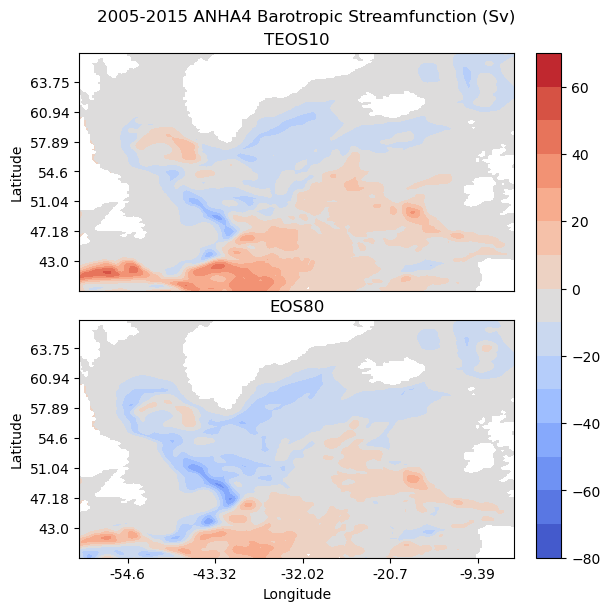

In [29]:
barotropic_plotter(v_eos, anha4mask, [baro_teos, baro_eos], labels = ['TEOS10', 'EOS80'])

In [48]:
over_eos = overturning_sf(v_eos, anha4mask).compute()

(50, 800)


In [49]:
over_teos = overturning_sf(v_teos, anha4mask).compute()

(50, 800)


In [39]:
anha4mask['nav_lat'][250:450, 200]

<xarray.DataArray 'nav_lat' (y: 200)>
array([38.646088, 38.840557, 39.034515, 39.227955, 39.420883, 39.613297,
       39.805195, 39.996582, 40.187458, 40.37782 , 40.56767 , 40.75701 ,
       40.94584 , 41.13416 , 41.321968, 41.50927 , 41.696064, 41.882347,
       42.068127, 42.253403, 42.43817 , 42.622437, 42.8062  , 42.98946 ,
       43.17222 , 43.354477, 43.536236, 43.717495, 43.89826 , 44.078526,
       44.258297, 44.437576, 44.61636 , 44.79465 , 44.972454, 45.149765,
       45.326588, 45.502926, 45.678776, 45.854137, 46.02902 , 46.20342 ,
       46.37734 , 46.550774, 46.723736, 46.896217, 47.068222, 47.239758,
       47.410816, 47.5814  , 47.751522, 47.92117 , 48.09035 , 48.259068,
       48.42732 , 48.595108, 48.762432, 48.9293  , 49.095707, 49.26166 ,
       49.42716 , 49.592197, 49.75679 , 49.92093 , 50.084618, 50.24786 ,
       50.41066 , 50.57301 , 50.73492 , 50.89639 , 51.05742 , 51.218006,
       51.378162, 51.537884, 51.69717 , 51.856026, 52.01445 , 52.172447,
       52.330017, 52.487164, 52.643887, 52.80019 , 52.95607 , 53.111534,
       53.266582, 53.421215, 53.575436, 53.729244, 53.88264 , 54.035633,
       54.188217, 54.340397, 54.492172, 54.643547, 54.79452 , 54.9451  ,
       55.09528 , 55.245068, 55.394463, 55.543465, 55.692078, 55.8403  ,
       55.98814 , 56.135593, 56.28266 , 56.42935 , 56.57566 , 56.721592,
       56.867146, 57.012325, 57.15713 , 57.301563, 57.44563 , 57.58932 ,
       57.73265 , 57.875614, 58.01821 , 58.160446, 58.302322, 58.443836,
       58.58499 , 58.725792, 58.866238, 59.00633 , 59.14607 , 59.285458,
       59.424496, 59.563187, 59.70153 , 59.83953 , 59.977184, 60.114494,
       60.251465, 60.388096, 60.524387, 60.66034 , 60.795956, 60.931236,
       61.066185, 61.200798, 61.33508 , 61.46903 , 61.60265 , 61.73594 ,
       61.868904, 62.00154 , 62.13385 , 62.265835, 62.397495, 62.528835,
       62.659847, 62.790543, 62.920914, 63.050964, 63.180695, 63.31011 ,
       63.4392  , 63.567978, 63.696434, 63.824574, 63.9524  , 64.07991 ,
       64.2071  , 64.33398 , 64.46054 , 64.586784, 64.712715, 64.83833 ,
       64.96363 , 65.088615, 65.21329 , 65.33765 , 65.46169 , 65.58542 ,
       65.70883 , 65.831924, 65.954704, 66.07716 , 66.19931 , 66.321144,
       66.44265 , 66.56384 , 66.684715, 66.80527 , 66.9255  , 67.04541 ,
       67.16499 , 67.284256, 67.40319 , 67.521805, 67.64008 , 67.75804 ,
       67.87566 , 67.99295 , 68.10991 , 68.22653 , 68.34282 , 68.45876 ,
       68.57437 , 68.68964 ], dtype=float32)
Dimensions without coordinates: y

In [81]:
def overturning_plotter(ds, ds_mask, mosfs, labels =[]):

    num = len(mosfs)

    fig, axes = plt.subplots(num,1, figsize=(6,6))
    plt.rcParams['figure.constrained_layout.use'] = True

    for x in range(num):
        sf = axes[x].contourf(ds_mask['nav_lat'][250:450, 250], ds_mask['nav_lev'][:], mosfs[x][:,250:450] / 1e6, np.arange(-20, 20, 2), cmap = 'coolwarm')
        axes[x].invert_yaxis()
        axes[x].set_title(labels[x])
        axes[x].set_ylabel('Depth (m)')
        #axes[x].set_yticks(np.arange(0,50,10)[1:], ds_mask['nav_lev'].values[::10][1:])
        #axes[x].set_xticks([])

        
    axes[-1].set_xlabel('Latitude')
    #axes[-1].set_xticks(np.arange(250, 450, 25), np.trunc(ds_mask.nav_lat.values[250:450, 250][::25] * 100) / 100)

    #axes[-1].set_xticks(np.arange(25,225, 45), np.trunc(ds_mask.nav_lon.values[250, 175:375][::45] * 100) / 100)

    fig.suptitle('2005-2015 ANHA4 Overturning Streamfunction (Sv)')
    fig.colorbar(sf, ax = axes[:])
    plt.savefig('/mnt/storage5/grace/data/figs/overturning.jpg')
    plt.show()

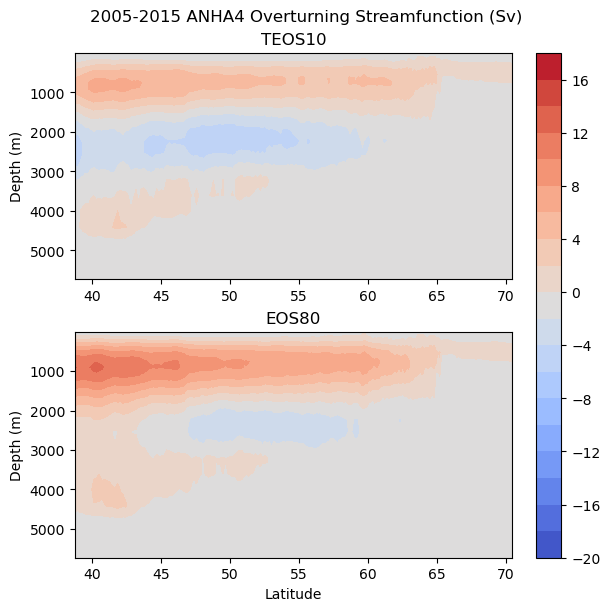

In [82]:
overturning_plotter(v_eos, anha4mask, [over_teos, over_eos], labels = ['TEOS10', 'EOS80'])

In [165]:
c = xr.open_dataset('/mnt/storage5/grace/data/EGK502/ANHA4-EGK502_y2008m06d19_gridT.nc')

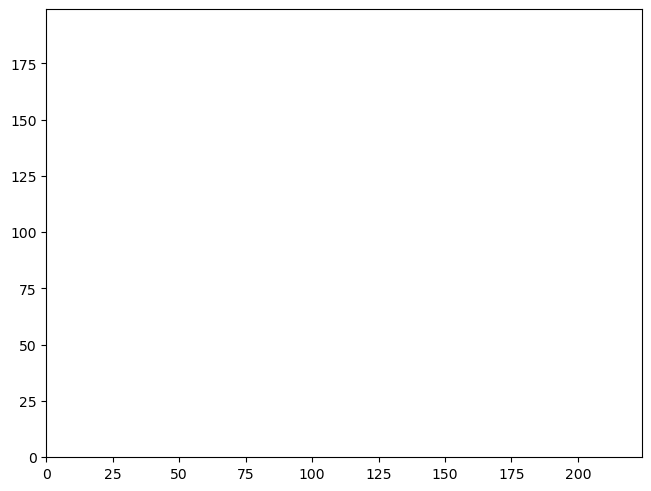

In [166]:
plt.contourf(c['somxlts'][0,250:450,150:375])

In [159]:
mld_djf_teos = mld_calc(anha4mask, t_teos['somxlts'], 'DJF')
mld_djf_eos = mld_calc(anha4mask, t_eos['somxlts'], 'DJF')

/tmp/ipykernel_4127960/293667591.py:8: RuntimeWarning: All-NaN axis encountered
  mlds_seas['maxes'] = np.nanmax(mldd)
/tmp/ipykernel_4127960/293667591.py:9: RuntimeWarning: All-NaN axis encountered
  mlds_seas['mins'] = np.nanmin(mldd)


In [158]:
def mld_calc(ds_mask, mld, season):
    
    mlds_seas = {'s_label': season}
    
    mldd = mld[:,250:450,150:375].groupby('time_counter.season')[season].mean('time_counter')
    #v = np.where(ds_mask['tmask'][0,0,250:450,150:375], mldd, np.nan)
    mlds_seas['vals'] = mldd
    mlds_seas['maxes'] = np.nanmax(mldd)
    mlds_seas['mins'] = np.nanmin(mldd)
    
    return mlds_seas    

In [121]:
def mld_plotter(ds, ds_mask, mlds, labels = []):

    fig, axes = plt.subplots(2, 1, figsize=(6,6))
    plt.rcParams['figure.constrained_layout.use'] = True

    min = np.nanmin([mlds[0]['mins'], mlds[1]['mins']])
    max = np.nanmax([mlds[0]['maxes'], mlds[1]['maxes']])

    for x in range(2):
        
        b = axes[x].contourf(mlds[x]['vals'], np.linspace(min, max, 20), cmap = 'viridis')#, extend='min')
        axes[x].set_title(labels[x])
        axes[x].set_ylabel('Latitude')
        axes[x].set_yticks(np.arange(25,200, 25), np.trunc(ds_mask.nav_lat.values[275:450, 150][::25] * 100) / 100)
        axes[x].set_xticks([])

    axes[-1].set_xlabel('Longitude')
    axes[-1].set_xticks(np.arange(25,225, 45), np.trunc(ds_mask.nav_lon.values[250, 175:375][::45] * 100) / 100)

    fig.suptitle('2005-2015 ANHA4 '+mlds[0]['s_label']+ ' Mixed Layer Depth (m)')
    fig.colorbar(b, ax = axes[:])
    plt.savefig('/mnt/storage5/grace/data/figs/mld' +mlds[0]['s_label']+'.jpg')
    plt.show()

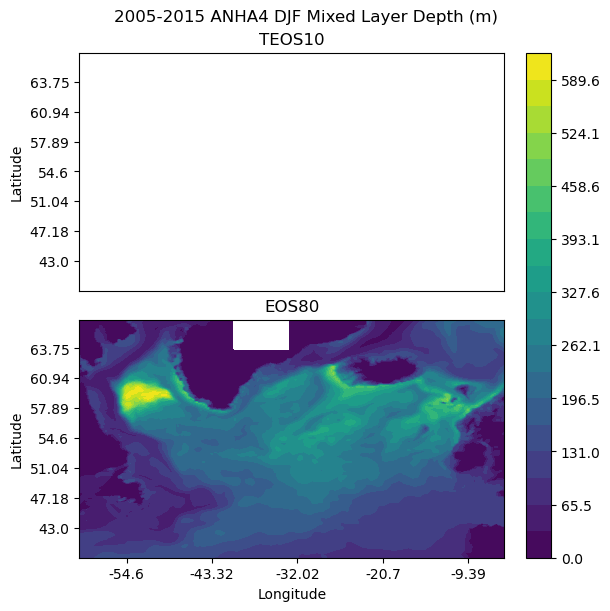

In [122]:
mld_plotter(t_eos, anha4mask, [mld_djf_teos, mld_djf_eos], labels = ['TEOS10', 'EOS80'])

In [125]:
mld_mam_teos = mld_calc(t_eos, anha4mask, t_teos['somxlts'][:], 'MAM')
mld_mam_eos = mld_calc(t_eos, anha4mask, t_eos['somxlts'][:], 'MAM')

/tmp/ipykernel_4127960/405668842.py:59: RuntimeWarning: All-NaN axis encountered
  mlds_seas['maxes'] = np.nanmax(mldd)
/tmp/ipykernel_4127960/405668842.py:60: RuntimeWarning: All-NaN axis encountered
  mlds_seas['mins'] = np.nanmin(mldd)


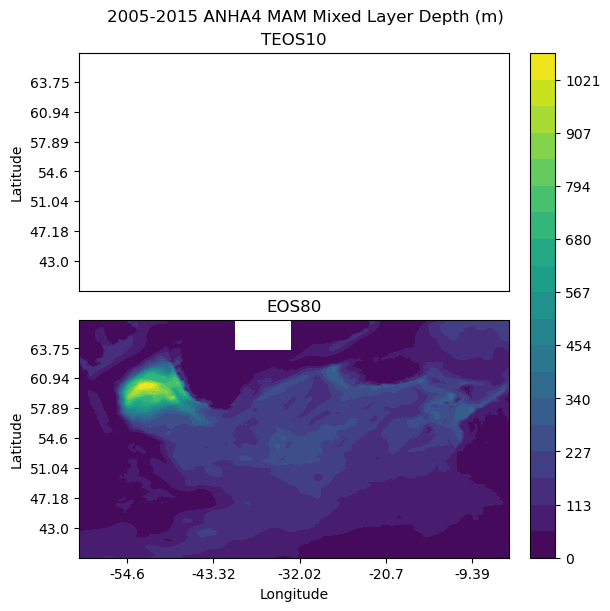

In [126]:
mld_plotter(t_eos, anha4mask, [mld_mam_teos, mld_mam_eos], labels = ['TEOS10', 'EOS80'])

In [148]:
def ssh_trend(ds, ds_mask):
    nsc = 1e9*60*60*24*365
    ssh_trends = {}
    ssh = ds['sossheig'][:,250:450,150:375].polyfit(dim="time_counter", deg=1)['polyfit_coefficients'][0].values * nsc
    
    v = np.where(ds_mask['tmask'][0,0,250:450,150:375], ssh, np.nan)
    ssh_trends['vals'] = v
    ssh_trends['maxes'] = np.nanmax(v)
    ssh_trends['mins'] = np.nanmin(v)

    return ssh_trends

In [149]:
ssh_teos = ssh_trend(t_teos, anha4mask)
ssh_eos = ssh_trend(t_eos, anha4mask)

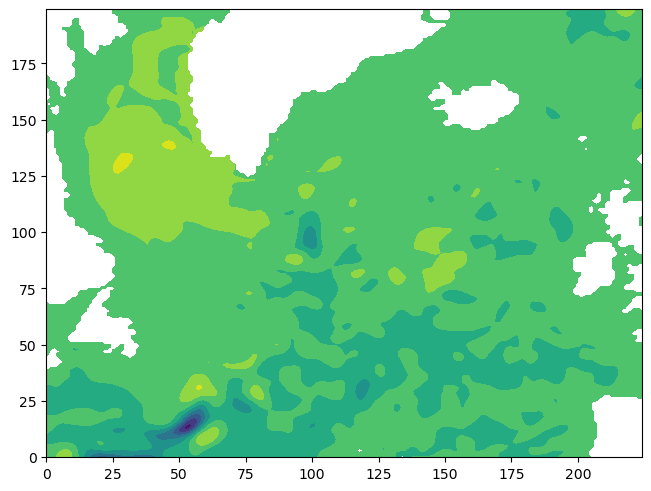

In [150]:
plt.contourf(ssh_teos['vals'] - ssh_eos['vals'])

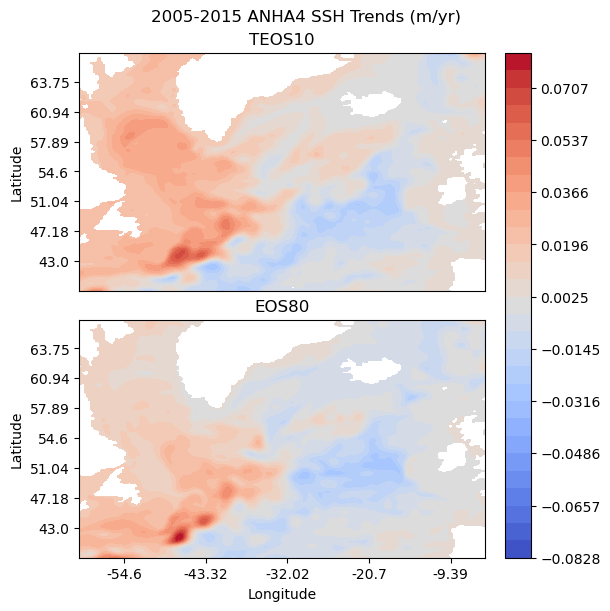

In [155]:
ssh_plotter(t_eos, anha4mask, [ssh_teos, ssh_eos], labels = ['TEOS10', 'EOS80'])